In [40]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict ,Annotated , Literal
from pydantic import BaseModel , Field
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import operator

In [41]:
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [42]:
class QuadState(TypedDict):
    a: int 
    b: int 
    c: int
    
    equation: str
    discriminant:float
    result:str
     

In [44]:
def showEquation(state: QuadState):
    equation = f"{state['a']}x*2 + {state['b']}x + {state['c']}"
    return {"equation" : equation}

def calculateDiscriminant(state: QuadState):
    d = state['b']**2 - (4*state['a']*state['c'])
    return {"discriminant" : d}

def realRoots(state:QuadState):
    root1 =  (-state['b'] + state['discriminant']**0.5)/2*state['a']
    root2 =  (-state['b'] - state['discriminant']**0.5)/2*state['a']
    result = f"The roots are {root1} and {root2}"
    return {"result" : result}

def repeatedRoots(state:QuadState):
    root =  (-state['b'] )/2*state['a']
    result = f"The repeated root is {root}"
    return {"result" : result}

def noRealRoots(state:QuadState):
    result = f"There are no real roots"
    return {"result" : result}

def checkCondition(state: QuadState) -> Literal["realRoots" ,"repeatedRoots" , "noRealRoots"]:
    if state['discriminant']>0:
        return "realRoots"
    elif state['discriminant']==0:
        return "repetedRoots"
    if state['discriminant']<0:
        return "noRealRoots"

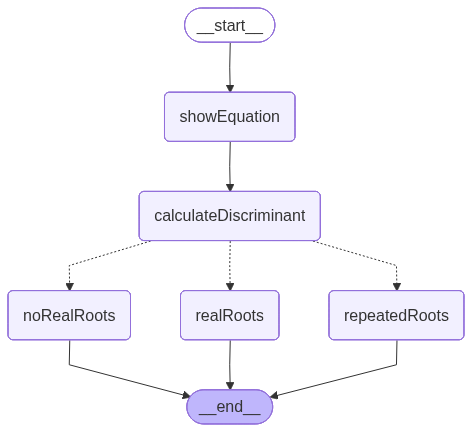

In [46]:
graph = StateGraph(QuadState)

graph.add_node("showEquation" , showEquation)
graph.add_node("calculateDiscriminant" , calculateDiscriminant)
graph.add_node("realRoots" , realRoots)
graph.add_node("repeatedRoots" , repeatedRoots)
graph.add_node("noRealRoots" , noRealRoots)


graph.add_edge(START , "showEquation")
graph.add_edge("showEquation" , "calculateDiscriminant")
graph.add_conditional_edges("calculateDiscriminant" , checkCondition)
graph.add_edge("realRoots" , END)
graph.add_edge("repeatedRoots" , END)
graph.add_edge("noRealRoots" , END)


graph.compile()
 



In [47]:
workflow = graph.compile()
initialState = {"a" :5 , "b": -5 , "c" : -5}
finalState = workflow.invoke(initialState)

In [48]:
finalState

{'a': 5,
 'b': -5,
 'c': -5,
 'equation': '5x*2 + -5x + -5',
 'discriminant': 125,
 'result': 'The roots are 40.45084971874737 and -15.450849718747373'}